# Ethiopia Climate Data Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on climate data for Ethiopia as part of the 10 Academy Week 0 challenge. The analysis includes data loading, cleaning, visualization, and basic insights extraction.

## Data Description
The dataset contains daily climate measurements for Ethiopia with the following key columns:
- **YEAR**: The year of the observation
- **DOY**: Day of year (1-365/366)
- **T2M**: Temperature at 2 meters above ground (°C)
- **PRECTOTCORR**: Corrected total precipitation (mm/day)
- Other meteorological variables

## Objectives
- Load and preprocess the climate data
- Handle missing values and duplicates
- Visualize temperature and precipitation trends
- Analyze correlations between variables
- Prepare cleaned data for further analysis

In [1]:
import pandas as pd

df = pd.read_csv('../data/ethiopia.csv')
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month

## Data Loading and Initial Processing
- Load the Ethiopia climate dataset from CSV
- Create a datetime column from YEAR and DOY
- Extract month from the date for seasonal analysis

## Data Cleaning
- Replace invalid values (-999) with NaN
- Check for and remove duplicate entries
- Handle missing values using forward fill

## Exploratory Data Analysis
- Visualize monthly average temperature trends
- Analyze monthly precipitation patterns
- Examine correlations between climate variables

In [2]:
import numpy as np
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,2026-03-30,3


In [3]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

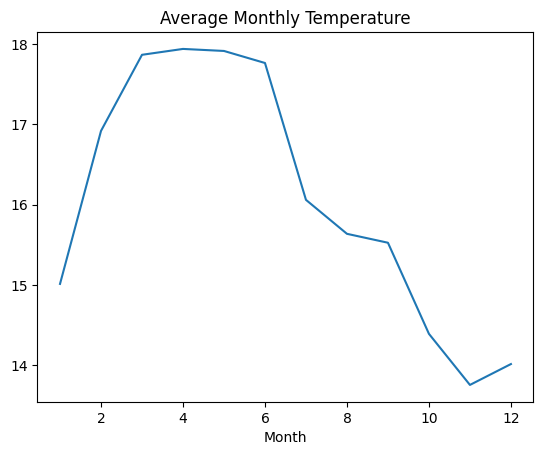

In [4]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Average Monthly Temperature")
plt.show()

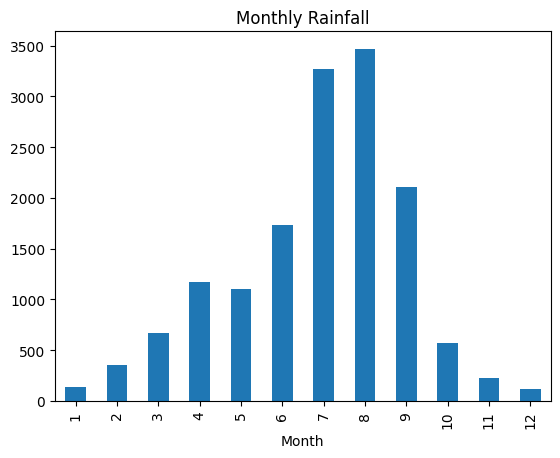

In [5]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

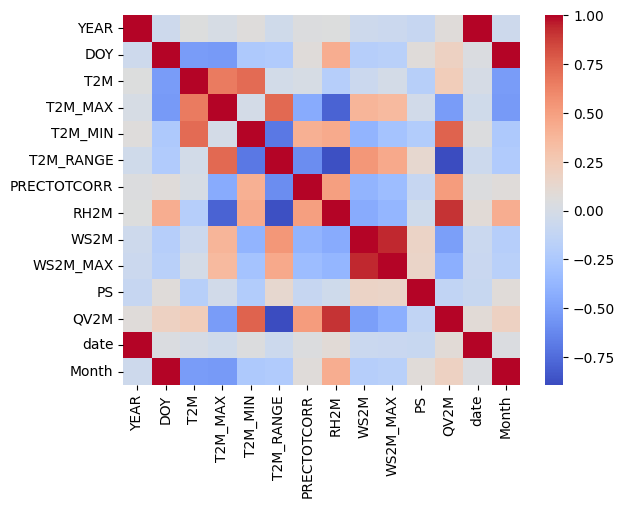

In [6]:
import seaborn as sns

sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [7]:
df.to_csv("../data/ethiopia.csv", index=False)

In [8]:
df.describe()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
date           0
Month          0
dtype: int64

In [9]:
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,2026-03-30,3


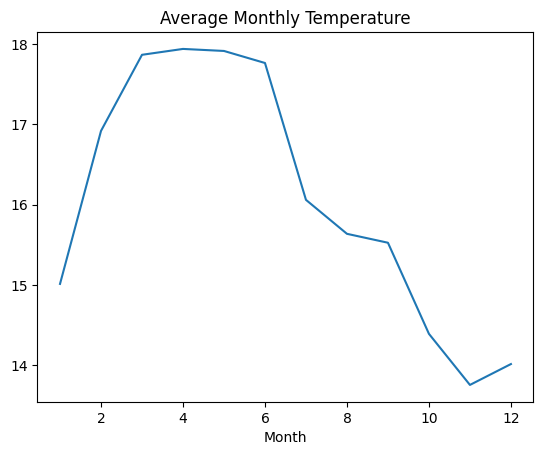

In [10]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Average Monthly Temperature")
plt.show()

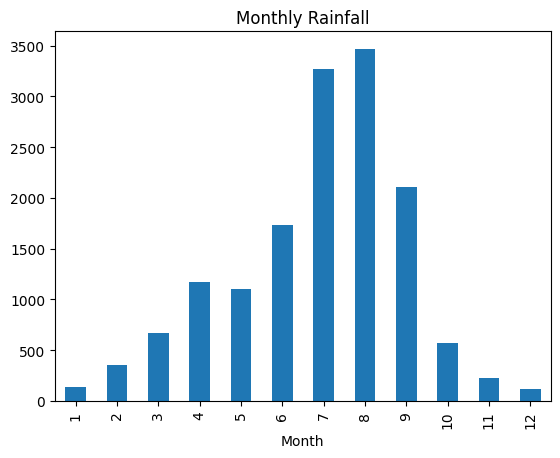

In [11]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

In [12]:
import pandas as pd

df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Ethiopia
